## Step-by-Step Guide to Initialize a GRN-Designer Model

#### Welcome to the guide for setting up and using the GRN-Designer (grnd) model! Below are the steps to initialize the model and descriptions for each parameter. Let’s dive in!

#### Before initializing the model, ensure all necessary libraries are imported.

In [13]:
import torch
import numpy as np
from grn_designer import GRNDesigner as grnd
from optimize import GradientOptimization as opt
from tensor_simulation import agent_simulation as sim_
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

### Prepare Inputs for the Model

In [24]:
d = h5py.File('data.h5', 'r')  
target = d['target'][:] # This is the target pattern (a 2D ndarray) that the model will try to optimize towards.

# The agent is a 3D ndarray used to initialize the population for the optimization process.
agent = np.zeros((3, 100, 100))  # Replace with your agent data
agent[1, :, :] = np.random.rand(100, 100)
agent[-1, 0, :3] = np.random.rand(3)
agent[-1, -1, :4] = (1, 100, 10, .1) # 1: number of genes, 100: max-iterations, 10: simulation-duration, .1: time-step 

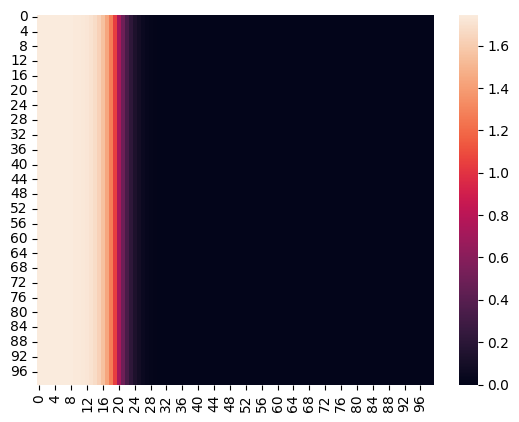

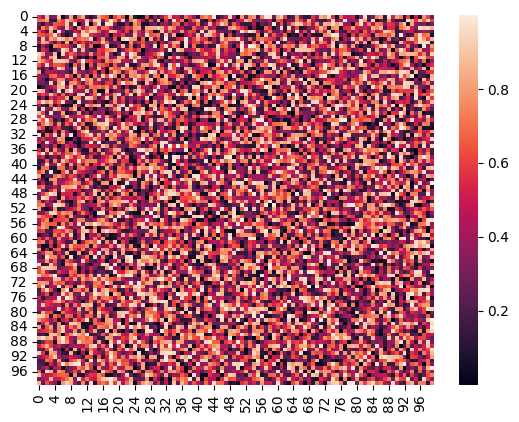

In [25]:
sns.heatmap(target)
plt.show()
sns.heatmap(agent[1])
plt.show()

### # Initialize the model

In [26]:
# For the sake of simplicity, we run the algorithm for a limited number of iterations (evolution_one_epochs=10, evolution_two_epochs=10, optimization_epochs=10)
model = grnd(
    target=target,  # Target pattern (replace with your 2D ndarray)
    agent=agent,  # Agent data (replace with your 3D ndarray)
    population=None,  # Optional: Use if continuing from a previous optimization
    population_size=10,  # Number of agents in each epoch
    evolution_one_epochs=10,  # Epochs for the first phase of evolutionary optimization
    evolution_two_epochs=10,  # Epochs for the second phase of evolutionary optimization
    optimization_epochs=20,  # Iterations for gradient-based optimization
    agent_shape=(3, 100, 100),  # Shape of the agent
    simulation_parameters={"max_simulation_epoch": 100, "simulation_stop_time": 10, "time_step": 0.1},  # Simulation details
    store_path="",  # Path to save results (edit with your directory)
    learning_rate=0.03,  # Learning rate for gradient optimization
    sim_mutation_rate=0.08,  # Mutation rate for simulation parameters
    initial_condition_mutation_rate=0.08,  # Mutation rate for initial conditions
    parameter_mutation_rate=0.07,  # Mutation rate for gene and interaction parameters
    species_insertion_mutation_rate=0.04,  # Mutation rate for adding new species
    connection_insertion_mutation_rate=0.07,  # Mutation rate for adding new interactions
    connection_deletion_mutation_rate=0.03,  # Mutation rate for deleting interactions
    cost_pattern_proportion=100,  # Adjust depending on the complexity of your GRN (e.g., 100 for 3 genes, 500 for 10 genes)
    crossover_alpha=0.4,  # Range factor for crossover during evolutionary optimization
    checkpoint_interval=10,  # Save intermediate results every 10 iterations
    gradient_optimizer="Adam",  # Choose "Adam" or "SGD" for gradient optimization
    lr_decay=False,  # Disable/Enable learning rate decay
    decay_steps=None,  # Number of steps before learning rate decay
    decay_rate=None,  # Learning rate decay factor
    gradient_optimization=True,  # Enable end-to-end gradient-based optimization
    parameter_optimization=True,  # Optimize rate constants for genes and interactions
    condition_optimization=True,  # Optimize initial conditions
    sim_mutation=True,  # Apply simulation parameter mutations
    initial_condition_mutation=True,  # Apply mutations to initial conditions
    parameter_mutation=True,  # Apply mutations to gene and interaction parameters
    species_insertion_mutation_one=True,  # Apply gene insertion mutations (phase 1)
    connection_insertion_mutation_one=True,  # Apply interaction insertion mutations (phase 1)
    connection_deletion_mutation_one=True,  # Apply interaction deletion mutations (phase 1)
    species_insertion_mutation_two=True,  # Apply gene insertion mutations (phase 2)
    connection_insertion_mutation_two=True,  # Apply interaction insertion mutations (phase 2)
    connection_deletion_mutation_two=True,  # Apply interaction deletion mutations (phase 2)
    initial_condition_crossover=True,  # Allow crossover for initial conditions
    parameter_crossover=True,  # Allow crossover for gene and interaction parameters
    simulation_crossover=True,  # Allow crossover for simulation parameters
    fixed_agent_shape=False,  # Keep the number of genes constant if True
    cost_alpha=0.6,  # Weight for MSE in loss calculation
    cost_beta=0.4,  # Weight for SSIM in loss calculation
    cost_constant=1,  # Value to replace NaN/Inf losses initially
    evolution_two_ratio=1,  # Proportion of population in phase 2
    zoom_=True,  # Enable zooming
    zoom_in_factor=0.5,  # Downscaling factor
    zoom_out_factor=2.0,  # Upscaling factor
    num_elite_agents=5,  # Retain top 5 agents for crossover
    simulation_min=(5, 0.01),  # Lower limits for simulation duration and time step
    simulation_max=(30, 0.3),  # Upper limits for simulation duration and time step
    initial_condition_min=0.0,  # Minimum initial condition value
    initial_condition_max=2.0,  # Maximum initial condition value
    parameter_min=(0.01, 0.01),  # Minimum values for gene and interaction rate constants
    parameter_max=(0.999, 2),  # Maximum values for gene and interaction rate constants
    num_init_genes=1,  # Number of genes for initializing agents
    shape_init_condition=False,  # Enable shape-based initialization of initial conditions
    radius_range=(5, 20),  # Range for the radius of initialized shapes
    conc_range=(0.7, 2.0)  # Range for concentration values in initialized shapes
)

In [27]:
population, final_agent = model.fit()         

___________________________________________________________________________
                           GRN-Designer Algorithm                          
___________________________________________________________________________

Epoch 1/20, Avg/Min Population Cost: 2.4680917263031006/0.6764987707138062
Epoch 2/20, Avg/Min Population Cost: 2.5216965675354004/0.6771670579910278
Epoch 3/20, Avg/Min Population Cost: 0.7612297534942627/0.6739099621772766
Epoch 4/20, Avg/Min Population Cost: 1.7872673273086548/0.6562986969947815
Epoch 5/20, Avg/Min Population Cost: 0.7430126070976257/0.6549793481826782
Epoch 6/20, Avg/Min Population Cost: 0.681665301322937/0.641889214515686
Epoch 7/20, Avg/Min Population Cost: 0.6697850227355957/0.6405715346336365
Epoch 8/20, Avg/Min Population Cost: 1.5386685132980347/0.6405087113380432
Epoch 9/20, Avg/Min Population Cost: 0.739891529083252/0.6409297585487366
Epoch 10/20, Avg/Min Population Cost: 0.6721060872077942/0.6391570568084717

______________________

C:\Users\yda2\Downloads\projects\grn-designer\src\optimization.py:138: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  parameters[f"initial_conditions_{c}"] = torch.tensor(
C:\Users\yda2\Downloads\projects\grn-designer\src\optimization.py:156: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  parameters[f"species_{s}"] = torch.tensor(


Iteration 1/20, Cost: 0.6540606617927551
Iteration 2/20, Cost: 0.642926037311554
Iteration 3/20, Cost: 0.6417254209518433
Iteration 4/20, Cost: 0.6323354840278625
Iteration 5/20, Cost: 0.6195926666259766
Iteration 6/20, Cost: 0.6081295013427734
Iteration 7/20, Cost: 0.6000644564628601
Iteration 8/20, Cost: 0.5924571752548218
Iteration 9/20, Cost: 0.5817743539810181
Iteration 10/20, Cost: 0.5700390338897705
Iteration 11/20, Cost: 0.5596652030944824
Iteration 12/20, Cost: 0.5503580570220947
Iteration 13/20, Cost: 0.5403668880462646
Iteration 14/20, Cost: 0.5289407968521118
Iteration 15/20, Cost: 0.5166585445404053
Iteration 16/20, Cost: 0.5048478841781616
Iteration 17/20, Cost: 0.4943518042564392
Iteration 18/20, Cost: 0.48420342803001404
Iteration 19/20, Cost: 0.47300925850868225
Iteration 20/20, Cost: 0.4611598551273346


In [28]:
for ag in population:
    print(ag.shape)
print(final_agent.shape)

(5, 100, 100)
(7, 100, 100)
(3, 100, 100)
(3, 100, 100)
(3, 100, 100)
(3, 100, 100)
(5, 100, 100)
(5, 100, 100)
(3, 100, 100)
(3, 100, 100)
torch.Size([7, 100, 100])


In [5]:
evo_result = h5py.File("evolutionary_result", "r")
adam_result = h5py.File("gradient_result", "r")
print(evo_result.keys())
print(adam_result.keys())
#evo_result.close()
#adam_result.close()
print(adam_result['agent'].shape)

<KeysViewHDF5 ['best_agent_one', 'best_agent_two', 'evolutionary_costs', 'original_target', 'run_time', 'simulation_results', 'zoomed_in_target']>
<KeysViewHDF5 ['agent', 'cost', 'gradient_costs', 'initial_conditions', 'run_time', 'simulation_results', 'target', 'time']>
(7, 100, 100)


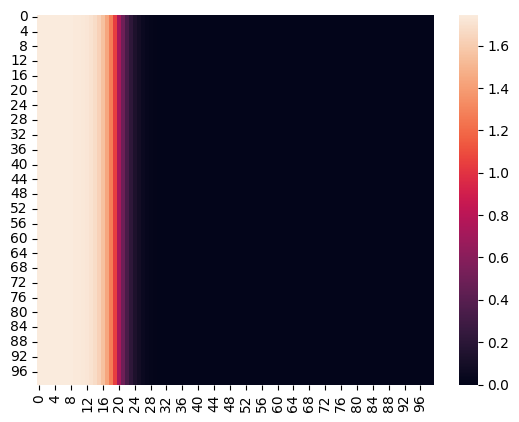

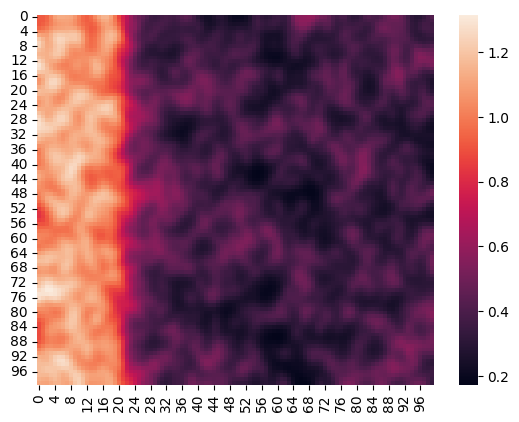

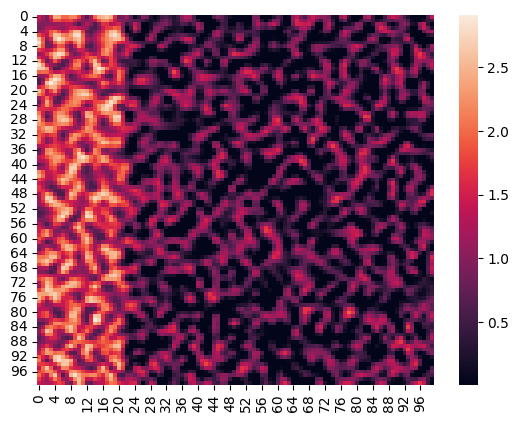

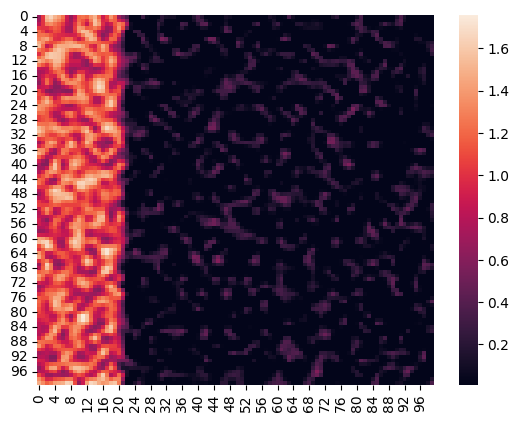

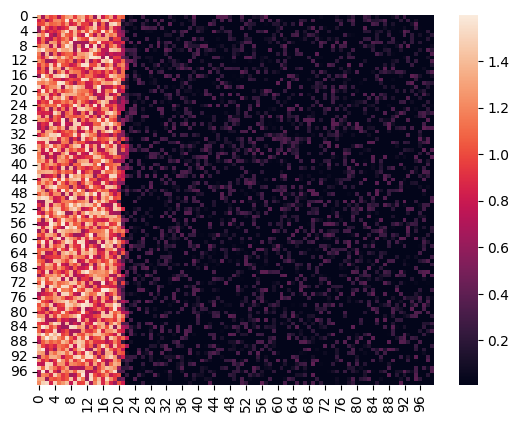

In [7]:
# targen pattern
sns.heatmap(adam_result['target'])
plt.show()

sns.heatmap(adam_result['simulation_results'][-1])
plt.show()

# inital conditions of the reporter gene
sns.heatmap(adam_result['initial_conditions'][0, -1])
plt.show()

# initial conditoons of the gene A
sns.heatmap(adam_result['initial_conditions'][1, -1])
plt.show()

# initial conditions of the gene B
sns.heatmap(adam_result['initial_conditions'][2, -1])
plt.show()

# How to resimulate an already optimized model

In [8]:
# uploade data
d = h5py.File('optimized_model.h5', 'r')
ag = d['agent'][:] # optimized model (grn)
tt = d['target'][:] # target pattern

In [9]:
obj = opt(
    target=torch.from_numpy(tt),
    path="",
    file_name="test"
)

In [10]:
param = obj.parameter_extraction(torch.from_numpy(ag), initial_condition_opt=None, parameter_opt=None) # extract parameters of the model

C:\Users\yda2\Downloads\projects\grn-designer\src\optimize.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  parameters[f"initial_conditions_{c}"] = torch.tensor(
C:\Users\yda2\Downloads\projects\grn-designer\src\optimize.py:122: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  parameters[f"species_{s}"] = torch.tensor(


In [11]:
ag_ = sim_(torch.from_numpy(ag), param[0], "cpu") # simulate the model

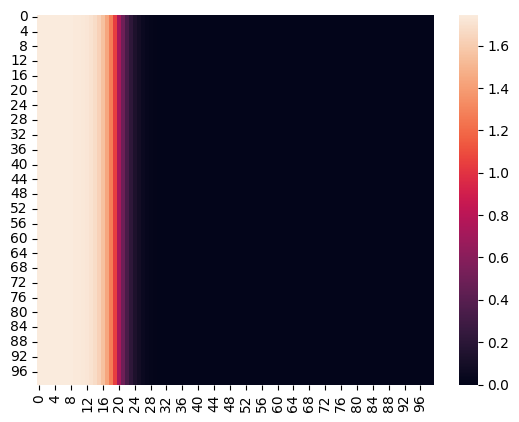

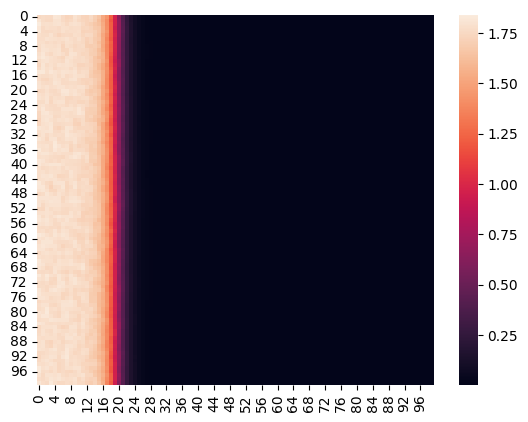

In [12]:
sns.heatmap(tt)
plt.show()
sns.heatmap(ag_[0])
plt.show()